<a href="https://colab.research.google.com/github/brittneymurugesan/hw5/blob/main/punk_tumor_adder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OH NO

A virus is coming where 50% of the cryptopunks will have contracted a disease where they get a white spot. The code below generates the disease. Your job is as follows

1. Generate the data as below
2. Train a convolutional neural network to classify punks as diseased or not
   1. Create training and validation sets.
   2. Contrast in the sensitivity, specificity and accuracy in both sets.

In [1]:

import urllib.request
import PIL
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, losses

## Open the image
imgURL = "https://raw.githubusercontent.com/larvalabs/cryptopunks/master/punks.png"
urllib.request.urlretrieve(imgURL, "cryptoPunksAll.jpg")
img = PIL.Image.open("cryptoPunksAll.jpg").convert("RGB")
imgArray = np.asarray(img)

n = 10000

finalArray = np.empty((n, 24, 24, 3))
for i in range(100):
  for j in range(100):
    a, b = 24 * i, 24 * (i + 1)
    c, d = 24 * j, 24 * (j + 1)
    idx = j + i * (100)
    finalArray[idx,:,:,:] = imgArray[a:b,c:d,:]


Our doctors have determined this is the region where the lesion occurs.

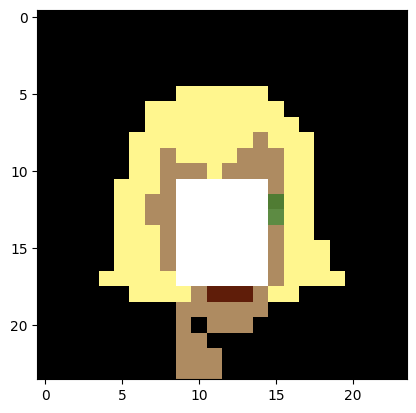

In [2]:

temp  =  finalArray[0,:,:,:].copy()

d2min, d2max = 9,14
d1min, d1max = 11,17

temp[d1min : (d1max + 1), d2min : (d2max + 1)] = 255

plt.imshow(temp.astype('uint8'))



In [3]:
cancerpunks = finalArray.copy()
label = np.zeros(n)

## Loop over the cryptopunks
for i in range(10000):
  flip = np.random.randint(0, 2)
  if flip is 1:
    label[i] = 1
    d1loc = np.random.randint(d1min, d1max + 1)
    d2loc = np.random.randint(d2min, d2max + 1)
    cancerpunks[i,d1loc,d2loc,:] = 255



<>:7: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:7: SyntaxWarning: "is" with a literal. Did you mean "=="?
<ipython-input-3-d1184c60a117>:7: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if flip is 1:


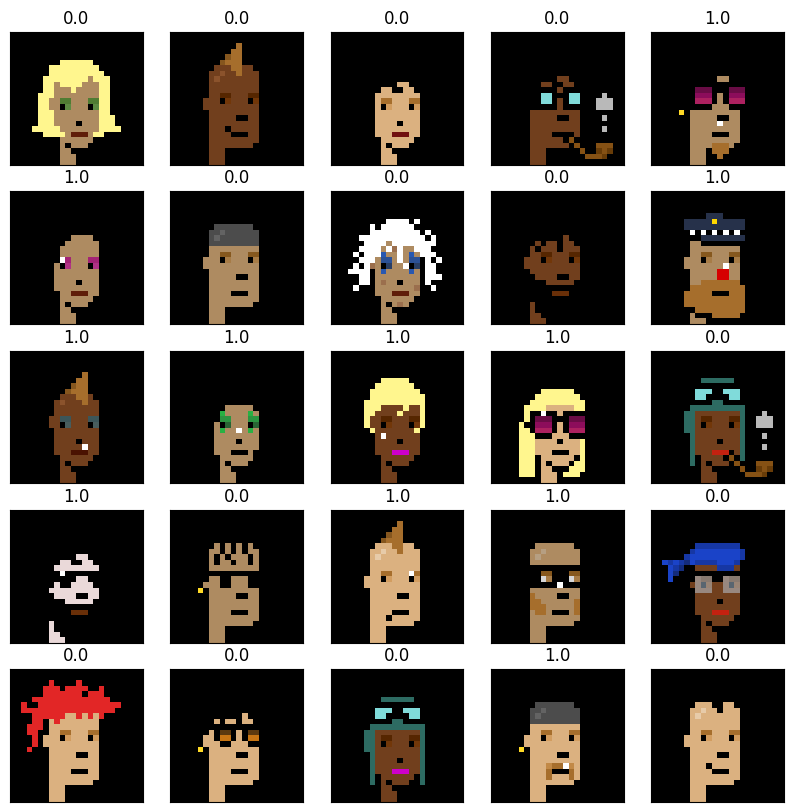

In [4]:
## plot some examples
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(cancerpunks[i,:,:,:].astype('uint8'))
  plt.title(label[i])

In [ ]:
## Brittney Murugesan: This is where my coding begins

In [5]:
# import packages

import urllib.request
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import gc
import torch.nn as nn
import torch.nn.functional as F

In [6]:
# Load the image
imgURL = "https://raw.githubusercontent.com/larvalabs/cryptopunks/master/punks.png"
urllib.request.urlretrieve(imgURL, "cryptoPunksAll.jpg")
img = Image.open("cryptoPunksAll.jpg").convert("RGB")
imgArray = np.asarray(img)

In [7]:
n = 10000

finalArray = np.empty((n, 24, 24, 3))
for i in range(100):
    for j in range(100):
        a, b = 24 * i, 24 * (i + 1)
        c, d = 24 * j, 24 * (j + 1)
        idx = j + i * (100)
        finalArray[idx,:,:,:] = imgArray[a:b,c:d,:]

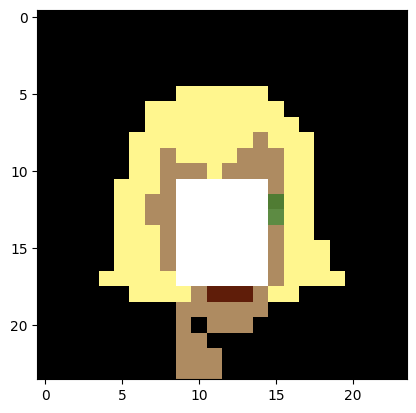

In [8]:
temp  =  finalArray[0,:,:,:].copy()

d2min, d2max = 9,14
d1min, d1max = 11,17

temp[d1min : (d1max + 1), d2min : (d2max + 1)] = 255

plt.imshow(temp.astype('uint8'))

In [9]:
cancerpunks = finalArray.copy()
label = np.zeros(n)

## Loop over the cryptopunks
for i in range(10000):
    flip = np.random.randint(0, 2)
    if flip == 1:
        label[i] = 1
        d1loc = np.random.randint(d1min, d1max + 1)
        d2loc = np.random.randint(d2min, d2max + 1)
        cancerpunks[i,d1loc,d2loc,:] = 255

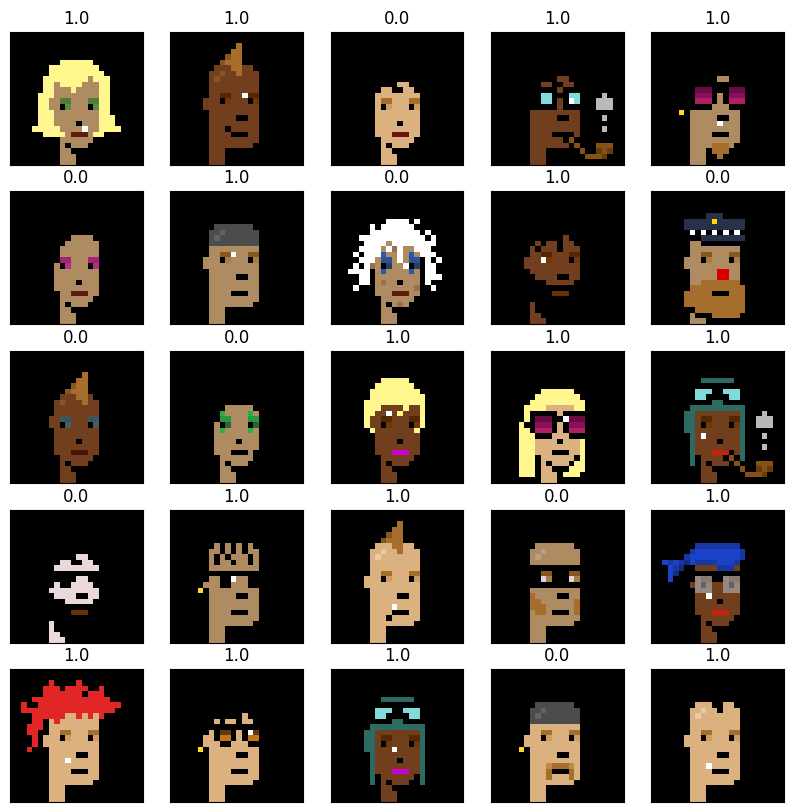

In [10]:
## plot some examples
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(cancerpunks[i,:,:,:].astype('uint8'))
    plt.title(label[i])

In [11]:
# Normalize the images
cancerpunks = cancerpunks / 255

In [12]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(cancerpunks, label, test_size=0.2, random_state=42)


In [13]:
# Define a custom dataset class
class PunksDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


In [14]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor()
])

In [15]:
# Create datasets
train_dataset = PunksDataset(X_train, y_train, transform=transform)
test_dataset = PunksDataset(X_test, y_test, transform=transform)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
# Define the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)  # Corrected size
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 3 * 3)  # Corrected size
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [18]:
model = CNN()


In [19]:
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
# Train the model
num_epochs = 5

In [21]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.float()  # Ensure inputs are float32
        labels = labels.float()  # Ensure labels are float32
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

In [25]:
# set up true positive, true negative, false positive, and false negative to develop a metric for sensitivity, specificity, and accuracy

def calculate_metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).float()  # Convert probabilities to binary predictions
    tp = ((y_true == 1) & (y_pred == 1)).sum().item()
    tn = ((y_true == 0) & (y_pred == 0)).sum().item()
    fp = ((y_true == 0) & (y_pred == 1)).sum().item()
    fn = ((y_true == 1) & (y_pred == 0)).sum().item()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

    return sensitivity, specificity, accuracy

In [28]:
# Evaluate on training set

model.eval()
train_labels = []
train_preds = []
with torch.no_grad():
    for inputs, labels in train_loader:
        inputs = inputs.float()
        labels = labels.float()
        outputs = model(inputs).squeeze()
        train_labels.extend(labels.numpy())
        train_preds.extend(outputs.numpy())

train_labels = torch.tensor(train_labels)
train_preds = torch.tensor(train_preds)
train_sensitivity, train_specificity, train_accuracy = calculate_metrics(train_labels, train_preds)

print(f"Training - Sensitivity: {train_sensitivity:.4f}, Specificity: {train_specificity:.4f}, Accuracy: {train_accuracy:.4f}")


Training - Sensitivity: 0.9852, Specificity: 0.9700, Accuracy: 0.9776


In [29]:
# Evaluate on validation set

val_labels = []
val_preds = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.float()
        labels = labels.float()
        outputs = model(inputs).squeeze()
        val_labels.extend(labels.numpy())
        val_preds.extend(outputs.numpy())

val_labels = torch.tensor(val_labels)
val_preds = torch.tensor(val_preds)
val_sensitivity, val_specificity, val_accuracy = calculate_metrics(val_labels, val_preds)

print(f"Validation - Sensitivity: {val_sensitivity:.4f}, Specificity: {val_specificity:.4f}, Accuracy: {val_accuracy:.4f}")

Validation - Sensitivity: 0.9711, Specificity: 0.9615, Accuracy: 0.9665
